# Parametric Number of Sampling Point Study

In this study we will investigate how the prediction accuracy influenced by number of sample point when we use during the initialization of the each local network for each subdomain. Number of sampling point will be used for per subdomain initialization will be increased within predifined intervals.

The study is performed on multiscale Laplacian PDE problem, where the mathematical and configuration details can be seen in "/experiments/2D/multiscale_laplacian_weak_scaling.ipynb".

In [1]:
import os
import sys
root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
print(root)
sys.path.append(root)

c:\Users\dogak\OneDrive\Belgeler\swim-pde-thesis


In [2]:
from swimpde_jax.domain import MultiLevelDecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.boundary import Dirichlet
from swimpde_jax.ansatz import BasicAnsatz, DecomposedBasicAnsatz
from swimpde_jax.equation import PlainEquation, Laplacian
from utils import normalized_l1_loss, plot_static_results_2D, compute_metrics, plot_swim_2D

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import jax.numpy as jnp
import numpy.typing as npt
from jax.typing import ArrayLike

import time
from functools import partial
import matplotlib.pyplot as plt

In [3]:
# Plot functions
def plot_target(x: npt.ArrayLike, title=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    vmin = np.nanmin(x)
    vmax = np.nanmax(x)
    im = ax.imshow(x, extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    if title:
        ax.set_title(title)
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    fig.colorbar(im, ax=ax, orientation='vertical')
    plt.tight_layout()
    plt.show()

### Problem Definition   (Closed form solution of Laplacian)

In [4]:
def laplacian_target(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Analytical solution definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)  
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1]))  

    solution = np.sum(sin_x1 * sin_x2, axis=0)  
    return ((1 / n_basis) * solution)[:, None]

def laplacian_forcing(x: npt.ArrayLike, n_basis: int) -> npt.ArrayLike:
    """ Source function definition."""
    coeffs = 2 ** np.arange(1, n_basis + 1)  
    omega_pi_squared = (coeffs * np.pi) ** 2  
    sin_x1 = np.sin(np.outer(coeffs, np.pi * x[:, 0]))  
    sin_x2 = np.sin(np.outer(coeffs, np.pi * x[:, 1])) 

    forcing = np.sum(omega_pi_squared[:, None] * sin_x1 * sin_x2, axis=0)  
    return ((2 / n_basis) * forcing)[:, None]

def constraining_operator(points: ArrayLike, sigma=0.2) -> ArrayLike:
    """
    [Cu](x) = tanh(x1/σ) tanh((1−x1)/σ) tanh(x2/σ) tanh((1−x2)/σ)
    """
    x, y = points[0], points[1]
    return (
        jnp.tanh(x / sigma) *
        jnp.tanh((1 - x) / sigma) *
        jnp.tanh(y / sigma) *
        jnp.tanh((1 - y) / sigma)
    )

In [5]:
# Configurations for determining problem difficulty
problem_configs = {
    1 : {"num_sin_basis": 1, "num_test_point_per_dim": 10},
    2 : {"num_sin_basis": 2, "num_test_point_per_dim": 20},
    3 : {"num_sin_basis": 3, "num_test_point_per_dim": 40},
    4 : {"num_sin_basis": 4, "num_test_point_per_dim": 80},
    5 : {"num_sin_basis": 5, "num_test_point_per_dim": 160},
    6 : {"num_sin_basis": 6, "num_test_point_per_dim": 320},
}

In [6]:
# General settings and dataset creation
DIFFICULTY = 2  # Problem difficulty

random_state = 17
domain_span = (
        [0, 0], # lower bounds
        [1, 1]  # upper bounds
    )
n_dim = len(domain_span)
num_points_per_dim_train = 320

# Creation of training set
x_train = np.linspace(domain_span[0][0], domain_span[1][0],  num_points_per_dim_train)
y_train = np.linspace(domain_span[0][1], domain_span[1][1],  num_points_per_dim_train)
train_inputs = np.stack(np.meshgrid(x_train, y_train), axis=-1).reshape(-1, n_dim)
train_targets = laplacian_target(
    x=train_inputs, 
    n_basis=problem_configs[DIFFICULTY]['num_sin_basis'])

# Creation of test set
x_test = np.linspace(domain_span[0][0], domain_span[1][0],  problem_configs[DIFFICULTY]['num_test_point_per_dim'])
y_test = np.linspace(domain_span[0][1], domain_span[1][1],  problem_configs[DIFFICULTY]['num_test_point_per_dim'])
test_inputs = np.stack(np.meshgrid(x_test, y_test), axis=-1).reshape(-1, n_dim)
test_targets = laplacian_target(
    x=test_inputs, 
    n_basis=problem_configs[DIFFICULTY]['num_sin_basis'])


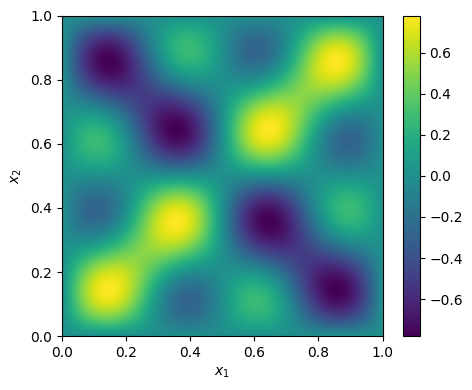

In [7]:
# Exact solution visualization
plot_target(train_targets.reshape(num_points_per_dim_train, -1))

### SOLUTION

In [8]:
partition_configs ={
    1 : {
        "one_level": [2],
        "multi_level": [1, 2],
        },
    2 : {
        "one_level": [4],
        "multi_level": [1, 2, 4],
        },
    3 : {
        "one_level": [8],
        "multi_level": [1, 2, 4, 8],
        },
    4 : {
        "one_level": [16],
        "multi_level": [1, 2, 4, 8, 16],
        },
    5 : {
        "one_level": [32],
        "multi_level": [1, 2, 4, 8, 16, 32],
        },
    6 : {
        "one_level": [64],
        "multi_level": [1, 2, 4, 8, 16, 32, 64],
        },
}

overlap_ratio = 1.9
window_fn = "gaussian"
swim_activation = "tanh"
swim_svd_cutoff = None
solver_type = "lstsq" # ["lstsq", "lsrn", "lsqr", "lsmr", "dask_svd"]
use_disk = False
regularization_scale = 1e-12

In [9]:
# Creating sampling config by keeping the number of swim basis per subdomain to number of resampling point per subdomain ratio fixed.
basis_to_sampling_ratio = 5
swim_num_basis_min = 50
swim_num_basis_max = 200
swim_num_basis_increment = 10

sampling_configs = {}
num_basis = swim_num_basis_min
config_idx = 1
while num_basis <= swim_num_basis_max:
    sampling_configs[config_idx] = {}
    sampling_configs[config_idx]['swim_num_basis'] = num_basis
    sampling_configs[config_idx]['min_num_sampling_points'] = num_basis * basis_to_sampling_ratio
    num_basis += swim_num_basis_increment
    config_idx += 1
    
print(sampling_configs)

{1: {'swim_num_basis': 50, 'min_num_sampling_points': 250}, 2: {'swim_num_basis': 60, 'min_num_sampling_points': 300}, 3: {'swim_num_basis': 70, 'min_num_sampling_points': 350}, 4: {'swim_num_basis': 80, 'min_num_sampling_points': 400}, 5: {'swim_num_basis': 90, 'min_num_sampling_points': 450}, 6: {'swim_num_basis': 100, 'min_num_sampling_points': 500}, 7: {'swim_num_basis': 110, 'min_num_sampling_points': 550}, 8: {'swim_num_basis': 120, 'min_num_sampling_points': 600}, 9: {'swim_num_basis': 130, 'min_num_sampling_points': 650}, 10: {'swim_num_basis': 140, 'min_num_sampling_points': 700}, 11: {'swim_num_basis': 150, 'min_num_sampling_points': 750}, 12: {'swim_num_basis': 160, 'min_num_sampling_points': 800}, 13: {'swim_num_basis': 170, 'min_num_sampling_points': 850}, 14: {'swim_num_basis': 180, 'min_num_sampling_points': 900}, 15: {'swim_num_basis': 190, 'min_num_sampling_points': 950}, 16: {'swim_num_basis': 200, 'min_num_sampling_points': 1000}}


In [ ]:
# Solution loop for SWIM-PDE
boundary_mask = (
    (train_inputs[:, 0] == domain_span[0][0]) |
    (train_inputs[:, 0] == domain_span[1][0]) |
    (train_inputs[:, 1] == domain_span[0][1]) |
    (train_inputs[:, 1] == domain_span[1][1])  
)

equation = Laplacian()

forcing_function = partial(
            laplacian_forcing,
            n_basis=problem_configs[DIFFICULTY]['num_sin_basis']
            )

boundary_condition = Dirichlet(g=forcing_function)


info_dict = {}
for conf_idx, sampling_config in sampling_configs.items():
    
    info_dict[conf_idx] = {}  
    info_dict[conf_idx]['num_min_sampling_point_per_subdomain'] = sampling_config['min_num_sampling_points']
    info_dict[conf_idx]['num_swim_basis'] = sampling_config['swim_num_basis']
    
    domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        num_partition_per_level=partition_configs[DIFFICULTY]['one_level'],
        overlap_ratio=overlap_ratio, 
        window_fn=window_fn,
        num_min_sample_point_per_subdomain=sampling_config['min_num_sampling_points'],
    )
    
    ansatz = DecomposedBasicAnsatz(
        n_basis=sampling_config['swim_num_basis'],
        activation=swim_activation,
        random_seed=random_state,
        svd_cutoff=swim_svd_cutoff,
        constraining_operator=partial(constraining_operator, sigma=0.25)
    )
    
    solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=regularization_scale,
        solver=solver_type,
        use_disk=use_disk,
    )   

    info_dict[conf_idx]['timing'] = {}
    info_dict[conf_idx]['error'] = {}
    info_dict[conf_idx]['error']['training'] = {}
    info_dict[conf_idx]['error']['test'] = {}
        
    # Training
    start_fit = time.time()
    solver.fit()
    end_fit = time.time()
    training_time = end_fit - start_fit
    info_dict[conf_idx]['timing']['training'] = f"{training_time:.16f} s"

    # Inference for training set
    start_inference = time.time()
    train_predictions, _, _ = solver.evaluate(train_inputs)
    end_inference = time.time()
    inference_time = end_inference - start_inference
    info_dict[conf_idx]['timing']['train_inference'] = f"{inference_time:.16f} s"

    # Error for training set predictions
    train_true_solution = forcing_function(train_inputs)
    normalized_l1_loss_train = normalized_l1_loss(train_predictions, train_true_solution)
    info_dict[conf_idx]['error']['training']['nmae'] = f"{normalized_l1_loss_train:.16f}"
    mse_loss_train = mean_squared_error(train_predictions, train_true_solution)
    info_dict[conf_idx]['error']['training']['mse'] = f"{mse_loss_train:.16f}"
    mae_loss_train = mean_absolute_error(train_predictions, train_true_solution)
    info_dict[conf_idx]['error']['training']['mae'] = f"{mae_loss_train:.16f}"

    # Inference for test set
    start_inference = time.time()
    test_predictions, _, _ = solver.evaluate(test_inputs)
    end_inference = time.time()
    inference_time = end_inference - start_inference
    info_dict[conf_idx]['timing']['test_inference'] = f"{inference_time:.16f} s"

    # Error for test set predictions
    test_true_solution = forcing_function(test_inputs)
    normalized_l1_loss_test = normalized_l1_loss(test_predictions, test_true_solution)
    info_dict[conf_idx]['error']['test']['nmae'] = f"{normalized_l1_loss_test:.16f}"
    mse_loss_test = mean_squared_error(test_predictions, test_true_solution)
    info_dict[conf_idx]['error']['test']['mse'] = f"{mse_loss_test:.16f}"
    mae_loss_test = mean_absolute_error(test_predictions, test_true_solution)
    info_dict[conf_idx]['error']['test']['mae'] = f"{mae_loss_test:.16f}"
    
info_dict


Initializing local SWIM networks...


Processing decomposed domains:   0%|          | 0/1 [02:35<?, ?domain/s]


In [11]:
def plot_results(data):

    metrics = ['nmae', 'mae', 'mse']
    num_sampling_points = [data[k]['num_swim_basis'] for k in sorted(data)]

    # Plot per metric with 2 subplots (training and test)
    for metric in metrics:
        training_errors = [float(data[k]['error']['training'][metric]) for k in sorted(data)]
        test_errors = [float(data[k]['error']['test'][metric]) for k in sorted(data)]

        fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        fig.suptitle(f'{metric.upper()} Error vs Number of Basis Function', fontsize=16)

        axs[0].semilogy(num_sampling_points, training_errors, marker='o', color='blue')
        axs[0].set_title('Training Error')
        axs[0].set_xlabel('Number of Basis Function')
        axs[0].set_ylabel(metric.upper())
        axs[0].grid(True, linestyle='--', alpha=0.6)

        axs[1].plot(num_sampling_points, test_errors, marker='s', color='green')
        axs[1].set_title('Test Error')
        axs[1].set_xlabel('Number of Basis Function')
        axs[1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()


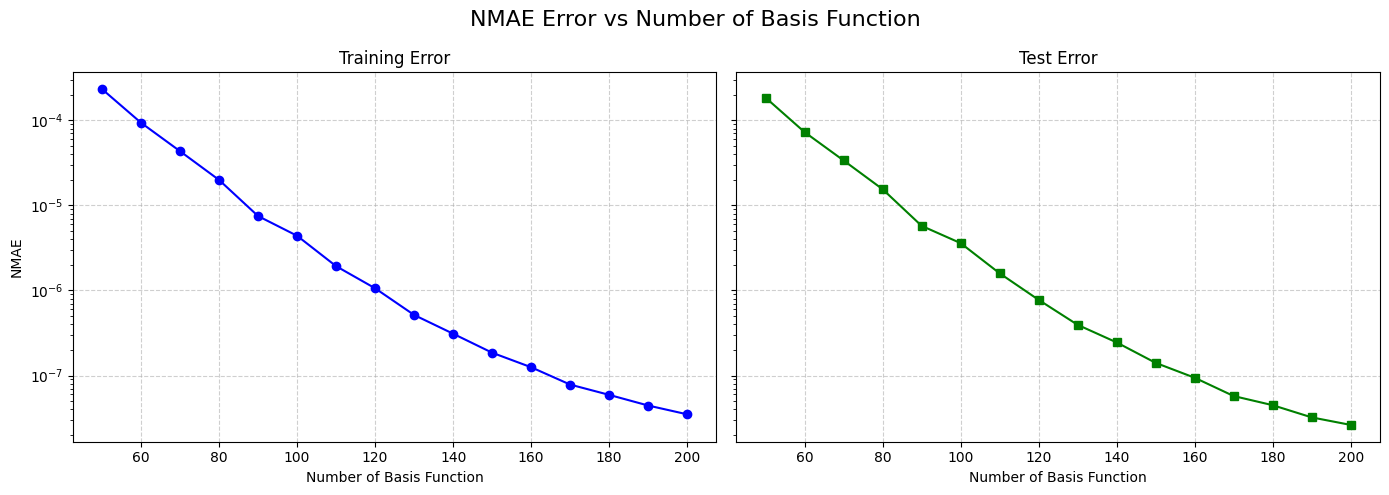

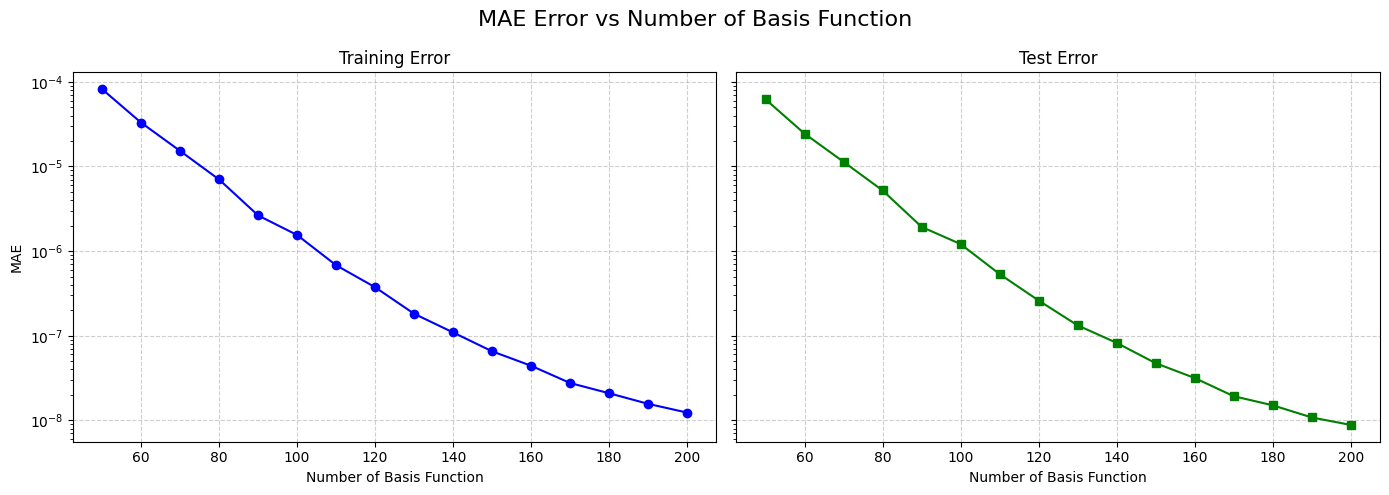

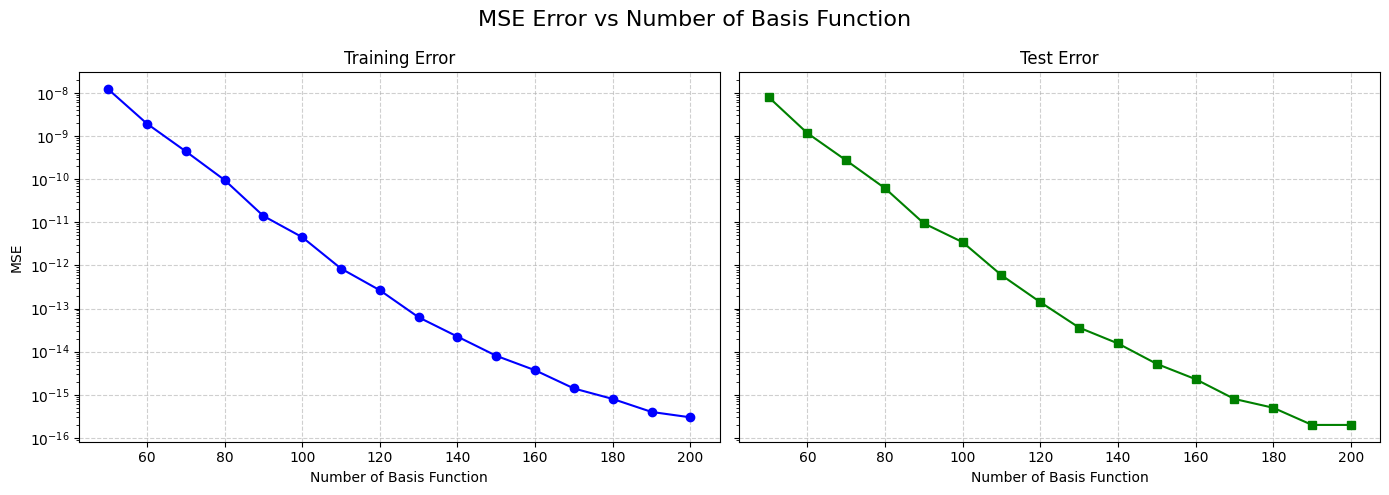

In [12]:
plot_results(data=info_dict)

### Evaluation

The obtained results shows that increasing the number of sampling points alongside with number of basis functions per subdomain SWIM network with a fixed rate, consistently improves the prediction accuracy.